In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import zarr
import os

def getP(path):
    flow_path = os.path.join(path, "MTs_red_flow.zarr")
    flow_array = zarr.open_array(flow_path, mode='r')
    
    x = flow_array[:, :, :, 0]  # x成分
    y = flow_array[:, :, :, 1]  # y成分
    # ベクトルの大きさを計算
    magnitude = np.sqrt(x**2 + y**2)

    # --- 1. Polar Order Parameter (P) の計算 ---
    # 全ベクトルの平均を計算
    mean_x = np.mean(x, axis=(1,2))
    mean_y = np.mean(y, axis=(1,2))
        
    # 平均ベクトルの大きさを、全ベクトルの平均の大きさで割って正規化
    # P = |<v>| / <|v|>
    mean_magnitude_of_vectors = np.mean(magnitude, axis=(1,2))
    magnitude_of_mean_vector = np.sqrt(mean_x**2 + mean_y**2)

    P = magnitude_of_mean_vector / mean_magnitude_of_vectors
    n_nanind = np.where(~np.isnan(P))
    PNan = P[n_nanind[0]]

    polar_path = os.path.join(path, "MTs_red_polar.zarr")
    Polar_parameter = zarr.open(polar_path, mode = 'w', shape = P.shape, dtype = P.dtype)
    Polar_parameter[:] = PNan

    return PNan

#path1 = '/Volumes/My Passport/Sasaki/MTsingleBeads/20260122/exp/MTs_red_flow.zarr'
path2 = '/Volumes/My Passport/Sasaki/MTsingleBeads/20260122/exp002'

#P1 = getP(path1)
P2 = getP(path2)

[Text(0.5, 0, 'Polar Order Parameter (P)'),
 Text(0, 0.5, 'Density'),
 (-0.01, 1.0),
 (0.0, 20.0)]

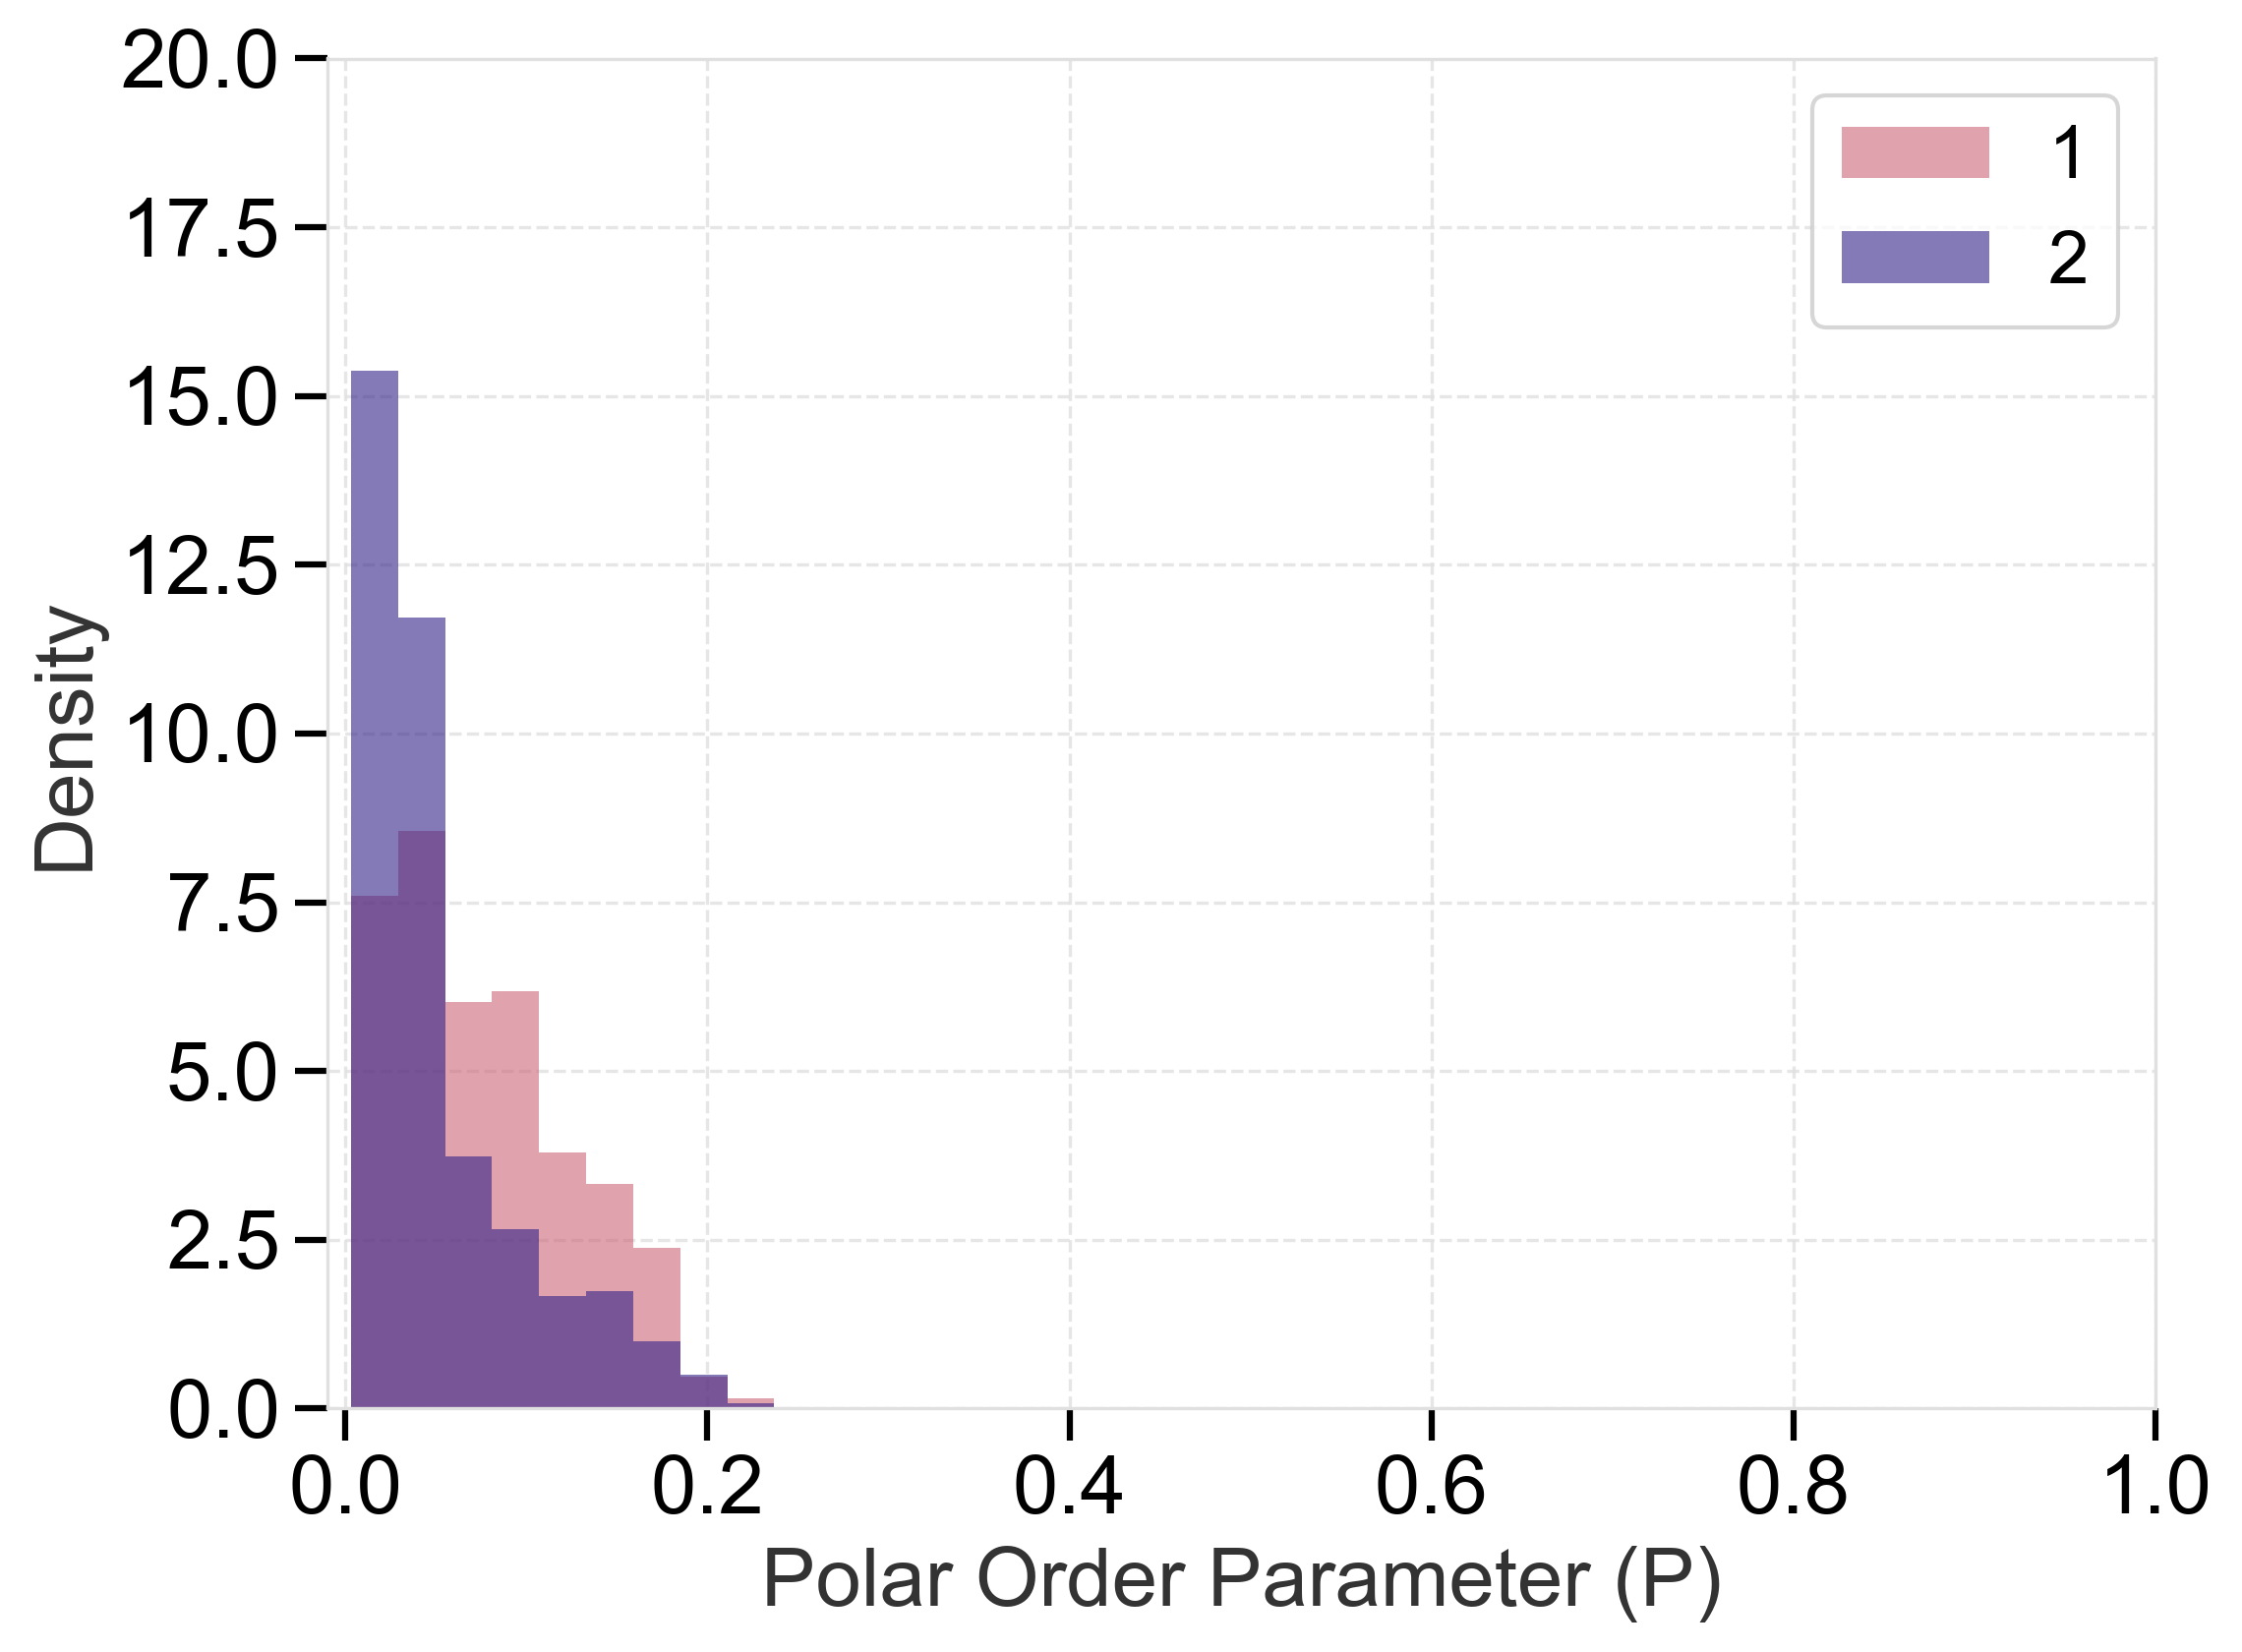

In [12]:
bins = np.histogram_bin_edges(P1, bins='sturges')
alpha = 0.6

plt.style.use('../libs/my_style.mplstyle')

fig, ax = plt.subplots()
ax.hist(P1, bins, density=True, label='1', alpha = alpha)
ax.hist(P2, bins, density=True, label='2', alpha = alpha)

ax.legend()

ax.set(xlabel='Polar Order Parameter (P)',
        ylabel='Density',
        xlim=(-0.01,1),
        ylim=(0,20)
       )

#fig.savefig(f'/Users/sasakinozomu/Documents/analysis/Output/P_hist.png', bbox_inches='tight')

[Text(0.5, 0, 'Time t[s]'),
 Text(0, 0.5, 'Polar Order Parameter (P)'),
 (-0.01, 1000.0),
 (0.0, 1.0)]

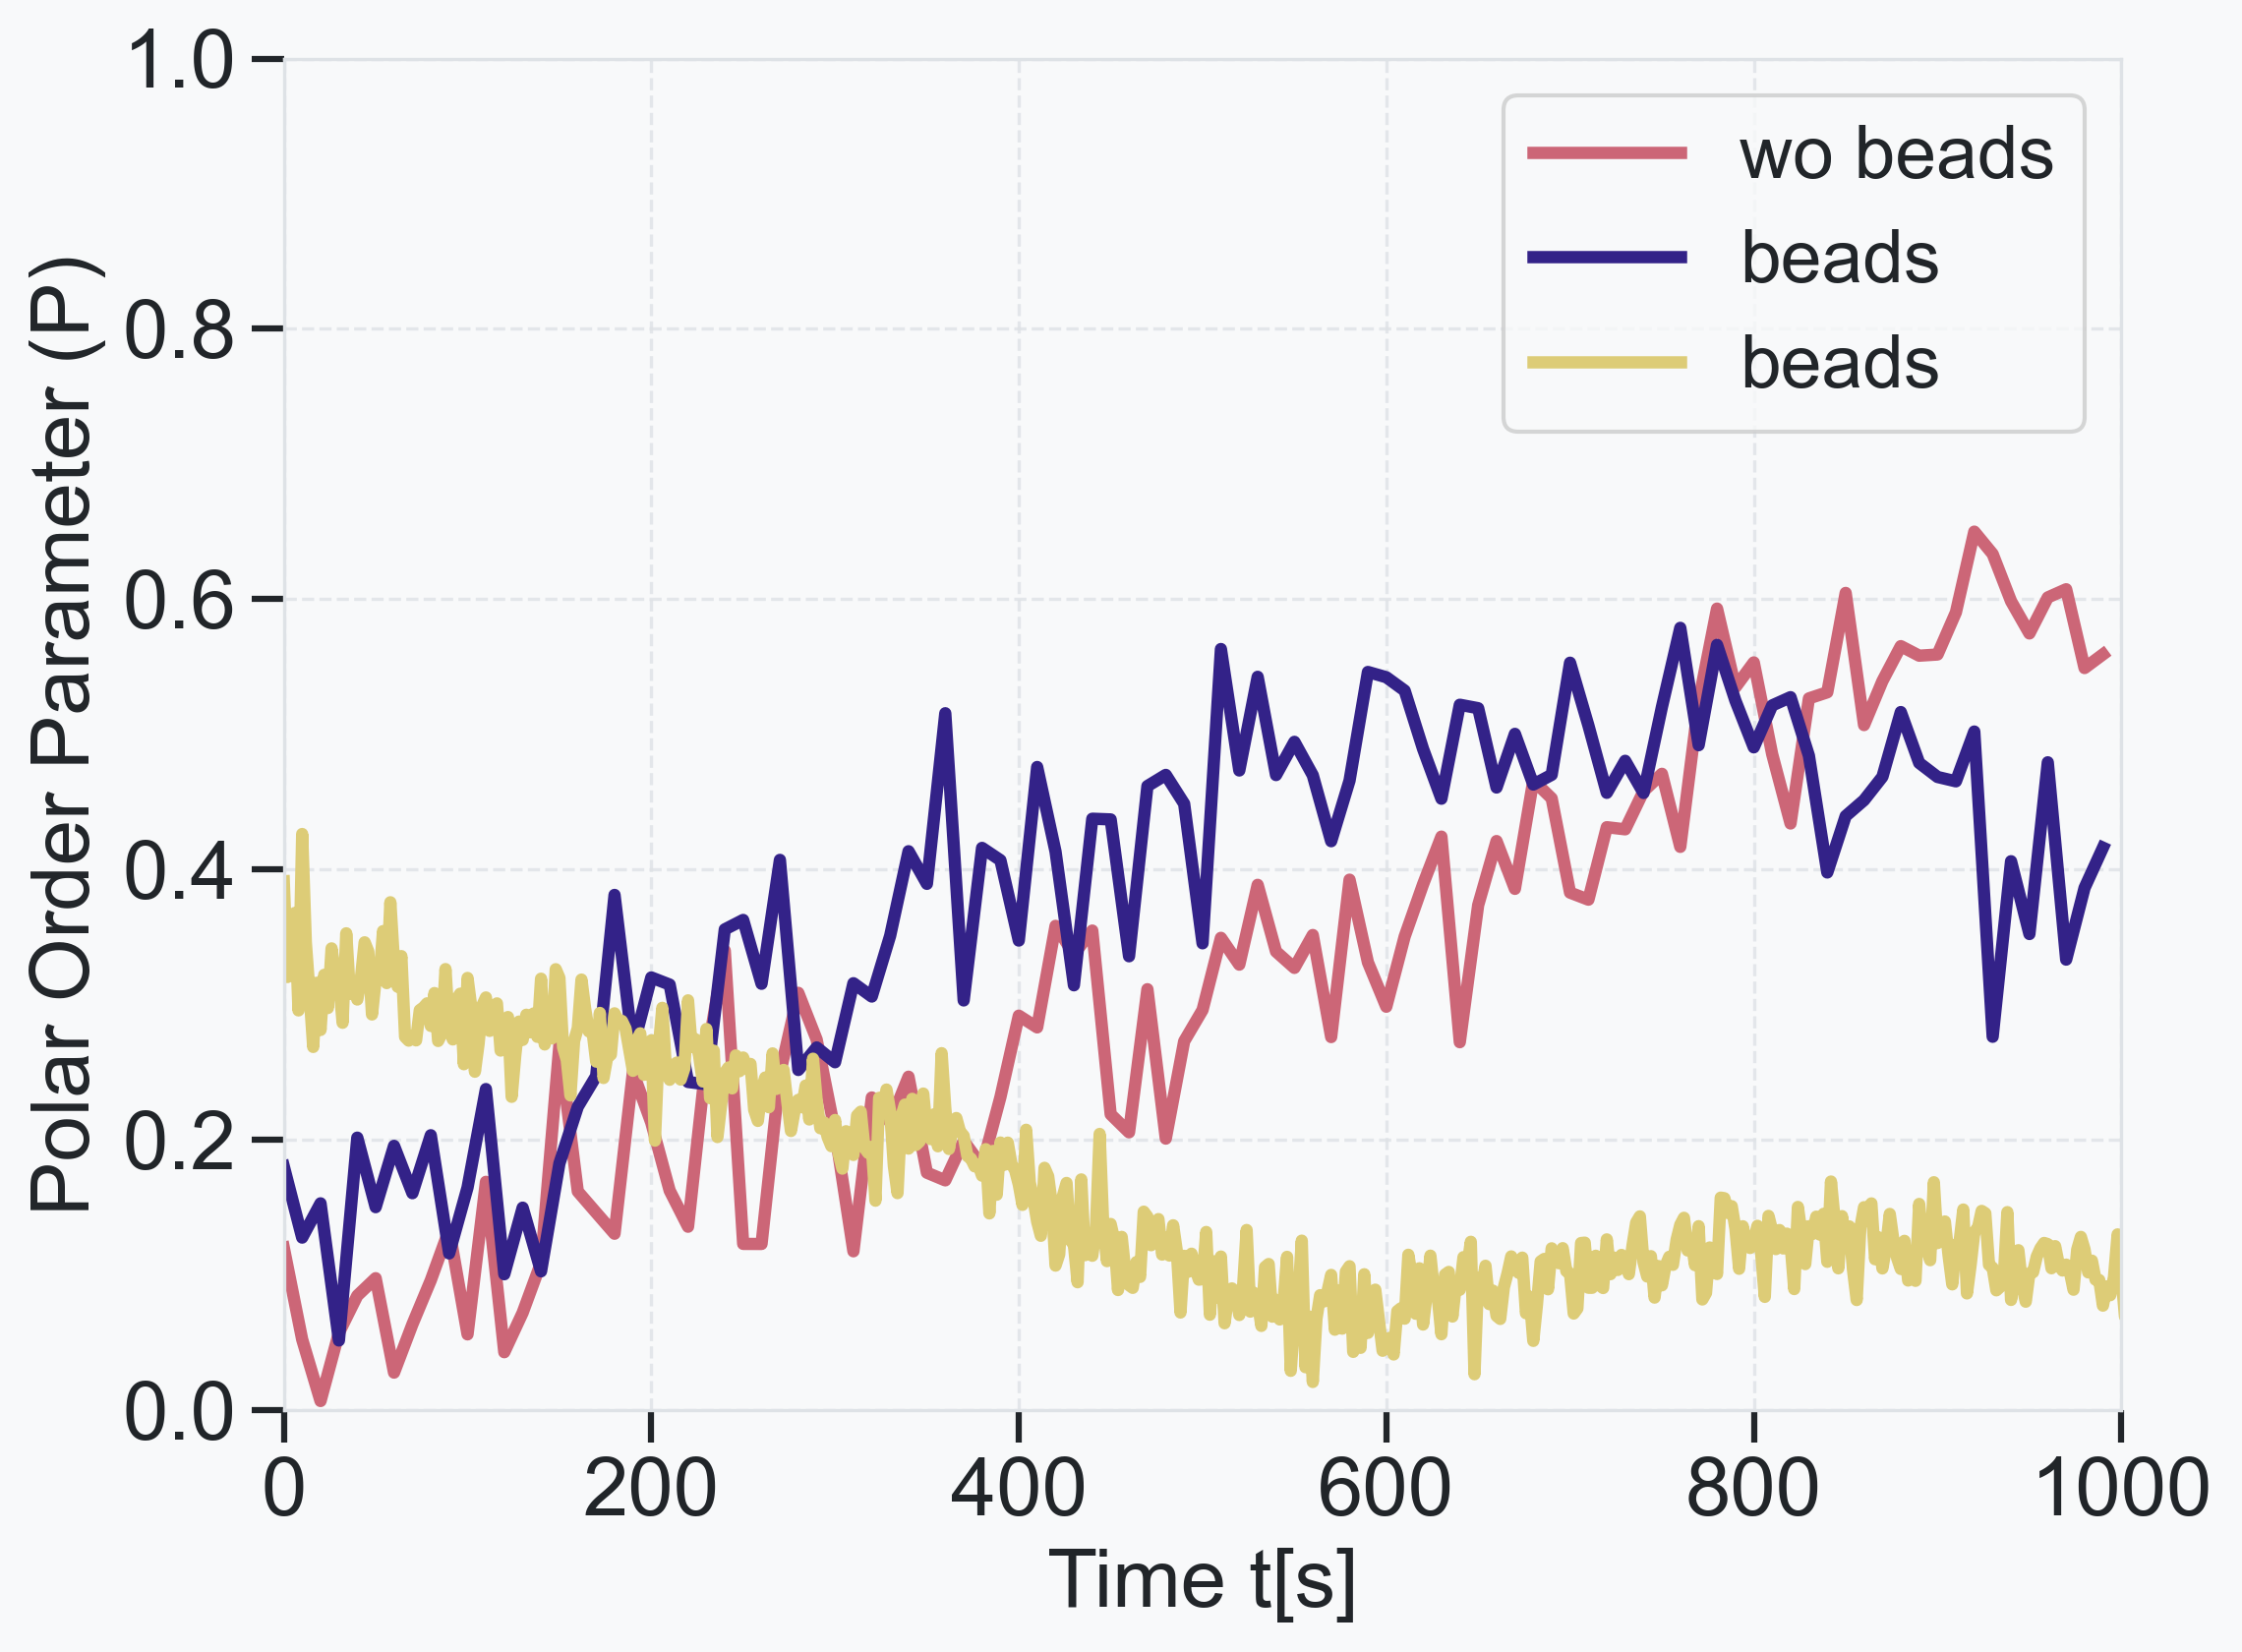

In [31]:
fig, ax = plt.subplots()

ax.plot(10*np.arange(P1.shape[0]-1), P1[:-1], label='wo beads')
ax.plot(10*np.arange(P2.shape[0]-1), P2[:-1], label='beads')
ax.plot(2*np.arange(P3.shape[0]-1), P3[:-1], label='beads')

ax.legend()

ax.set(xlabel='Time t[s]',
        ylabel='Polar Order Parameter (P)',
        xlim=(-0.01,1e3),
        ylim=(0,1)
       )

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import zarr
import os

mypass = '/media/sasaki/My Passport/Sasaki/MTSingleBeads'

path5 = os.path.join(mypass,"20260122/exp/optical_flow_output.zarr")
flow_array5 = zarr.open_array(path5, mode='r')

In [4]:
lambda5=flow_array5[2, 0, :, :]

(array([1.46000e+02, 1.82000e+02, 2.74000e+02, 2.91000e+02, 2.87000e+02,
        2.94000e+02, 2.94000e+02, 3.10000e+02, 3.15000e+02, 3.38000e+02,
        3.37000e+02, 3.68000e+02, 3.74000e+02, 3.81000e+02, 3.96000e+02,
        4.07000e+02, 4.12000e+02, 4.39000e+02, 5.89000e+02, 9.25000e+02,
        1.39100e+03, 2.38800e+03, 3.99700e+03, 9.04300e+03, 1.90390e+04,
        2.99360e+04, 4.24490e+04, 5.92280e+04, 7.83090e+04, 1.02780e+05,
        1.20995e+05, 1.39665e+05, 1.61125e+05, 1.72035e+05, 1.86741e+05,
        1.91803e+05, 1.93486e+05, 1.89499e+05, 1.91298e+05, 1.99255e+05,
        1.96668e+05, 1.90253e+05, 1.89819e+05, 1.82726e+05, 1.69306e+05,
        1.58455e+05, 1.47973e+05, 1.38297e+05, 1.31517e+05, 1.25171e+05,
        1.17405e+05, 1.09690e+05, 1.03469e+05, 9.25970e+04, 8.40980e+04,
        7.79230e+04, 7.53970e+04, 6.87780e+04, 6.33390e+04, 6.03690e+04,
        5.61650e+04, 5.25570e+04, 4.97970e+04, 4.71330e+04, 4.29580e+04,
        3.95110e+04, 3.74910e+04, 3.46890e+04, 3.23

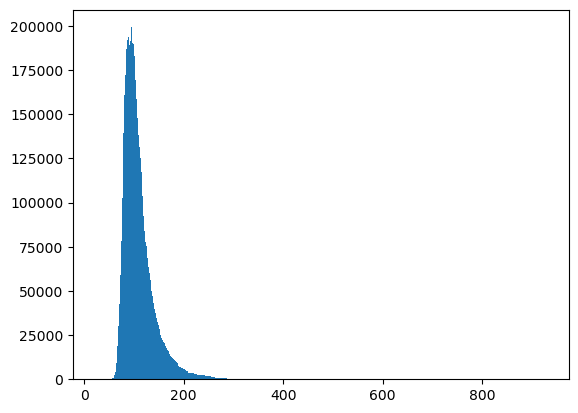

In [10]:
plt.hist(lambda5.reshape(-1), bins=500)